In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, PolynomialFeatures, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score)

In [2]:
df = pd.read_csv("penguins.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df["Species"].value_counts(normalize=True))

   CulmenLength  CulmenDepth  FlipperLength  BodyMass  Species
0          39.1         18.7          181.0    3750.0        0
1          39.5         17.4          186.0    3800.0        0
2          40.3         18.0          195.0    3250.0        0
3           NaN          NaN            NaN       NaN        0
4          36.7         19.3          193.0    3450.0        0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CulmenLength   342 non-null    float64
 1   CulmenDepth    342 non-null    float64
 2   FlipperLength  342 non-null    float64
 3   BodyMass       342 non-null    float64
 4   Species        344 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 13.6 KB
None
CulmenLength     2
CulmenDepth      2
FlipperLength    2
BodyMass         2
Species          0
dtype: int64
Species
0    0.441860
1    0.360465
2    0.197

In [3]:
df = df.dropna(subset=["Species"]) #usuwamy tylko brak w zm. docelowej

In [4]:
#braki w X zostaja i beda obsluzone przez SimpleImputer w Pipeline.
X = df.drop(columns=["Species"])
y = df["Species"]

In [5]:
print(y.isna().sum())

0


In [6]:
# Podzial na X i y

X = df.drop("Species", axis=1)
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

#numeryczne cechy
num_features = list(X.columns)

In [7]:
# preprocessing dla kazdego Pipeline'u

def make_scaled_preprocessor():
    numeric_preprocessing = Pipeline(steps=[
        ("fill_missings", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())])

    preprocessor = ColumnTransformer(transformers=[
        ("numeric_preprocessing", numeric_preprocessing, num_features)])

    return preprocessor


def make_tree_preprocessor():
    numeric_preprocessing = Pipeline(steps=[
        ("fill_missings", SimpleImputer(strategy="mean"))])

    preprocessor = ColumnTransformer(transformers=[
        ("numeric_preprocessing", numeric_preprocessing, num_features)])

    return preprocessor


def make_advanced_preprocessor():
    numeric_preprocessing = Pipeline(steps=[
        ("fill_missings", SimpleImputer(strategy="mean")),
        ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler_1", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("scaler_2", StandardScaler())])

    preprocessor = ColumnTransformer(transformers=[
        ("numeric_preprocessing", numeric_preprocessing, num_features)])

    return preprocessor

In [8]:
# Pipeline'y dla modeli

def make_lr_pipeline():
    return Pipeline(steps=[
        ("preprocessor", make_scaled_preprocessor()),
        ("model", LogisticRegression(max_iter=1000))])


def make_knn_pipeline():
    return Pipeline(steps=[
        ("preprocessor", make_scaled_preprocessor()),
        ("model", KNeighborsClassifier(n_neighbors=5))])


def make_tree_pipeline():
    return Pipeline(steps=[
        ("preprocessor", make_tree_preprocessor()),
        ("model", DecisionTreeClassifier(max_depth=3, random_state=42))])


def make_svm_pipeline():
    return Pipeline(steps=[
        ("preprocessor", make_scaled_preprocessor()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42))])


def make_rf_pipeline():
    return Pipeline(steps=[
        ("preprocessor", make_tree_preprocessor()),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))])


def make_gb_pipeline():
    return Pipeline(steps=[
        ("preprocessor", make_tree_preprocessor()),
        ("model", GradientBoostingClassifier(random_state=42))])


def make_advanced_lr_pipeline():
    return Pipeline(steps=[
        ("preprocessor", make_advanced_preprocessor()),
        ("model", LogisticRegression(max_iter=10000))])

In [9]:
# funkcja calculate_metrics

def calculate_metrics(
    model,
    name,
    X_checked,
    y_checked,
    metrics_results,
    roc_results):
    predictions = model.predict(X_checked)
    predictions_proba = model.predict_proba(X_checked)

    print(classification_report(y_checked, predictions))

    # Confusion matrix
    plt.figure()
    cm = confusion_matrix(y_checked, predictions)

    ax = sns.heatmap(
        cm,
        annot=True,
        cmap="Blues",
        fmt=".0f")
    
    ax.set_title("Confusion Matrix\n\n")
    ax.set_xlabel("\nPredicted Values")
    ax.set_ylabel("Actual Values")
    plt.show()

    # zapis danych do ROC
    roc_results = roc_results + [{
        "name": name,
        "classes": model.classes_,
        "y_true": y_checked,
        "predictions_proba": predictions_proba}]

    # ROC Curve
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], "k--")

    for roc_item in roc_results:
        y_true_bin = label_binarize(
            roc_item["y_true"],
            classes=roc_item["classes"])

        fpr, tpr, thresholds = roc_curve(
            y_true_bin.ravel(),
            roc_item["predictions_proba"].ravel())

        plt.plot(fpr, tpr, label=roc_item["name"])

    plt.xlabel("False Positive Rates")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

    f1_metric = f1_score(
        y_checked,
        predictions,
        average="macro")

    auc_metric = roc_auc_score(
        y_checked,
        predictions_proba,
        multi_class="ovr",
        labels=model.classes_)

    metrics_results = metrics_results + [{
        "Model": name,
        "F1_score": f1_metric,
        "AUC": auc_metric}]

    return metrics_results, roc_results

In [10]:
metrics_results = []
roc_results = []

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        14

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



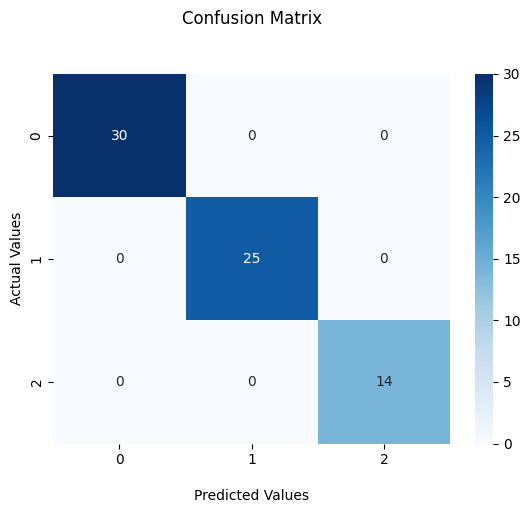

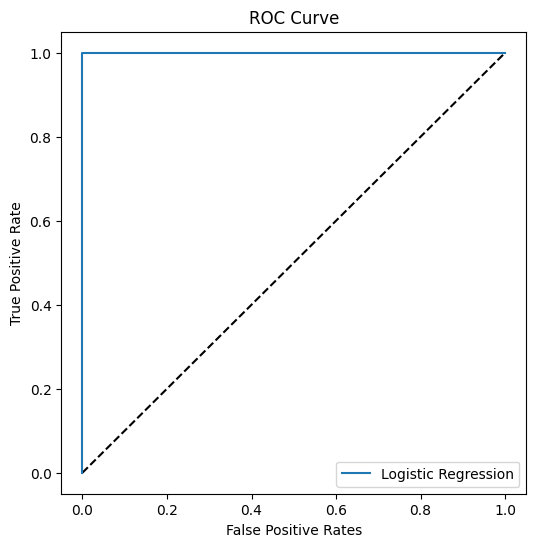

In [11]:
# Logistic Regression

lr_model = make_lr_pipeline()
lr_model.fit(X_train, y_train)

metrics_results, roc_results = calculate_metrics(
    lr_model,
    "Logistic Regression",
    X_test,
    y_test,
    metrics_results,
    roc_results)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      1.00      1.00        25
           2       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



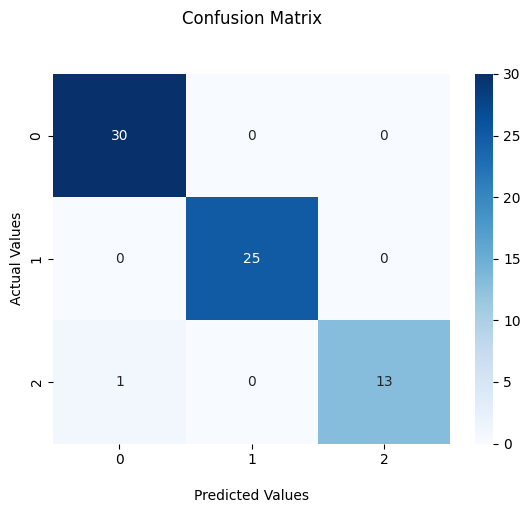

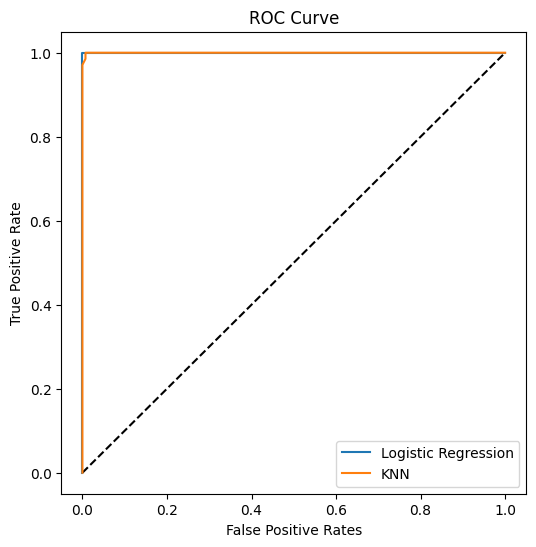

In [12]:
# KNN

knn_model = make_knn_pipeline()
knn_model.fit(X_train, y_train)

metrics_results, roc_results = calculate_metrics(
    knn_model,
    "KNN",
    X_test,
    y_test,
    metrics_results,
    roc_results)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        30
           1       0.96      1.00      0.98        25
           2       1.00      0.93      0.96        14

    accuracy                           0.97        69
   macro avg       0.98      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69



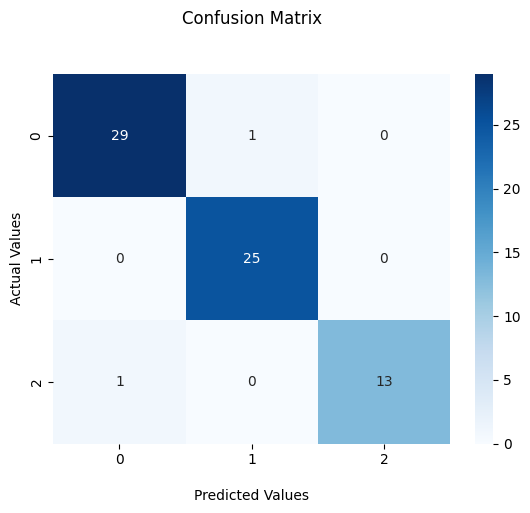

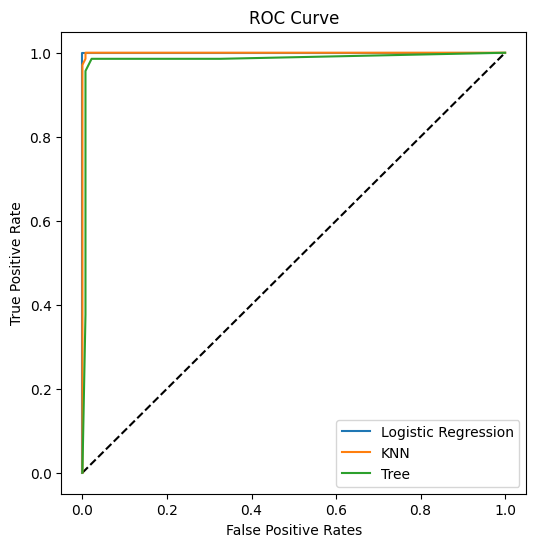

In [13]:
# Decission tree

model_tree = make_tree_pipeline()
model_tree.fit(X_train, y_train)

metrics_results, roc_results = calculate_metrics(
    model_tree,
    "Tree",
    X_test,
    y_test,
    metrics_results,
    roc_results)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        30
           1       1.00      1.00      1.00        25
           2       1.00      0.86      0.92        14

    accuracy                           0.97        69
   macro avg       0.98      0.95      0.96        69
weighted avg       0.97      0.97      0.97        69



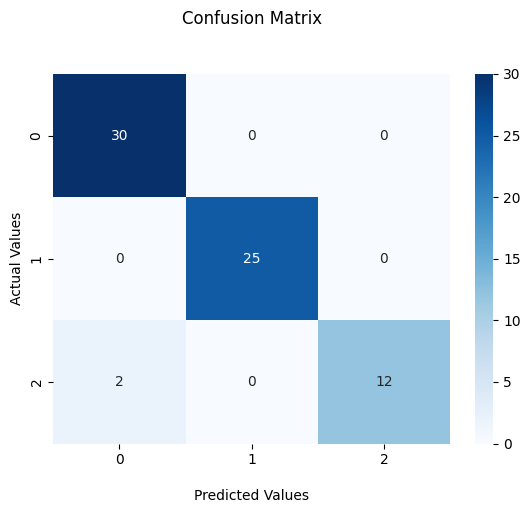

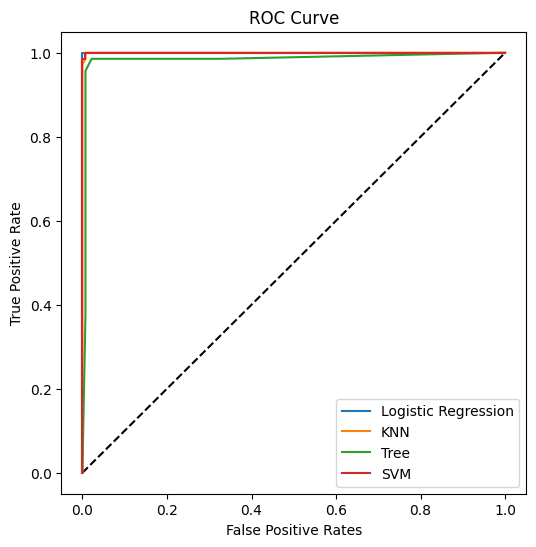

In [14]:
# SVM

svm_model = make_svm_pipeline()
svm_model.fit(X_train, y_train)

metrics_results, roc_results = calculate_metrics(
    svm_model,
    "SVM",
    X_test,
    y_test,
    metrics_results,
    roc_results)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        30
           1       0.96      1.00      0.98        25
           2       1.00      0.93      0.96        14

    accuracy                           0.97        69
   macro avg       0.98      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69



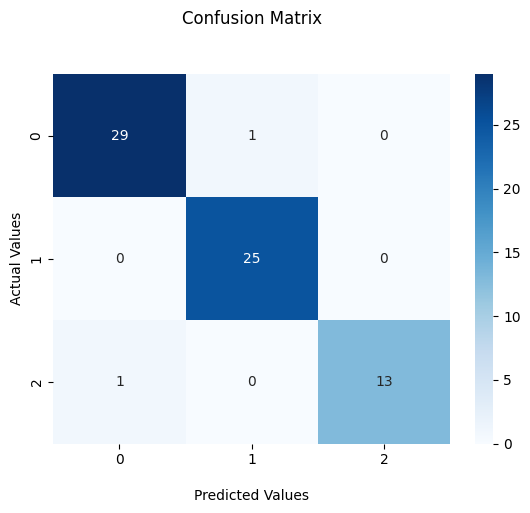

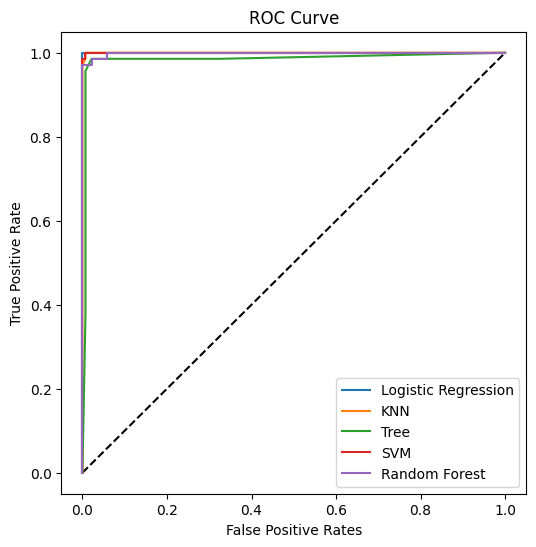

In [15]:
# Random forest

rf_model = make_rf_pipeline()
rf_model.fit(X_train, y_train)

metrics_results, roc_results = calculate_metrics(
    rf_model,
    "Random Forest",
    X_test,
    y_test,
    metrics_results,
    roc_results)

              precision    recall  f1-score   support

           0       0.94      0.97      0.95        30
           1       0.96      1.00      0.98        25
           2       1.00      0.86      0.92        14

    accuracy                           0.96        69
   macro avg       0.97      0.94      0.95        69
weighted avg       0.96      0.96      0.96        69



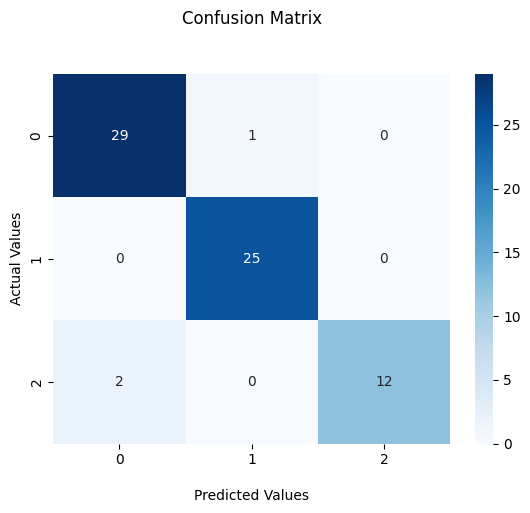

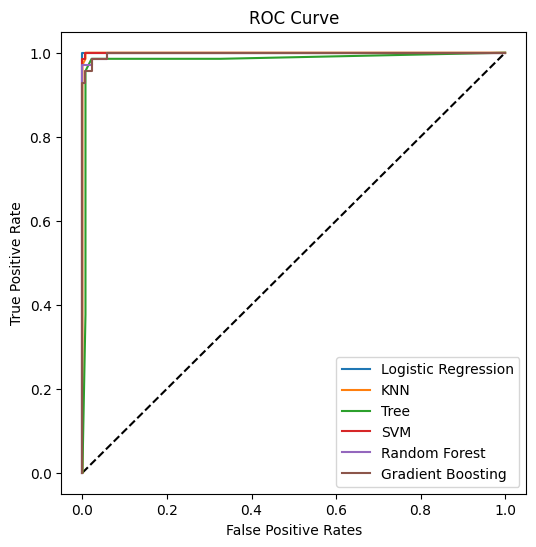

In [16]:
# Boosting

gb_model = make_gb_pipeline()
gb_model.fit(X_train, y_train)

metrics_results, roc_results = calculate_metrics(
    gb_model,
    "Gradient Boosting",
    X_test,
    y_test,
    metrics_results,
    roc_results)

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        30
           1       0.96      1.00      0.98        25
           2       1.00      1.00      1.00        14

    accuracy                           0.99        69
   macro avg       0.99      0.99      0.99        69
weighted avg       0.99      0.99      0.99        69



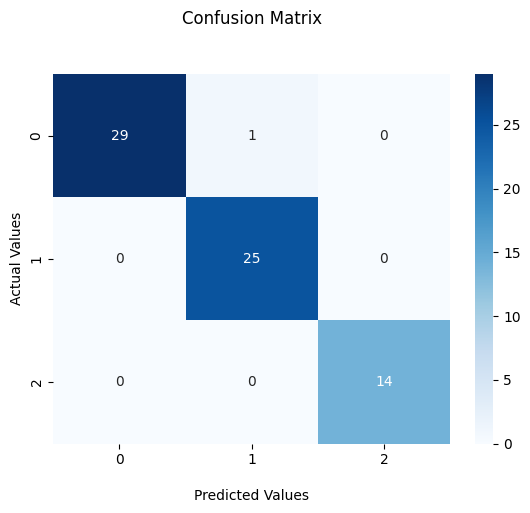

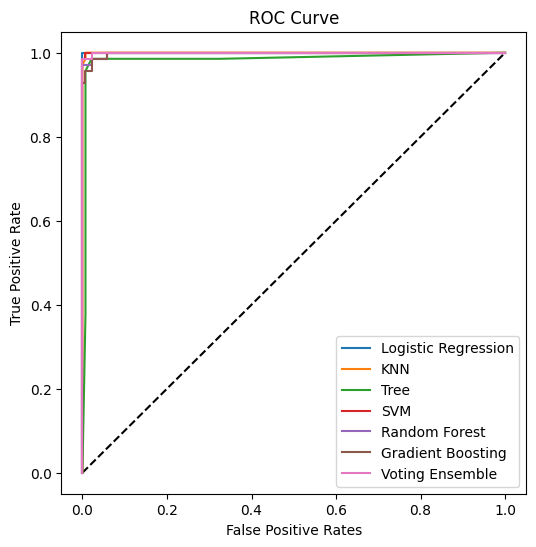

In [17]:
#Ensembling: VC ma wlasny pipeline

voting_model = VotingClassifier(
    estimators=[
        ("lr", make_lr_pipeline()),
        ("knn", make_knn_pipeline()),
        ("tree", make_tree_pipeline()),
        ("svm", make_svm_pipeline()),
        ("rf", make_rf_pipeline())],
    voting="soft")

voting_model.fit(X_train, y_train)

metrics_results, roc_results = calculate_metrics(
    voting_model,
    "Voting Ensemble",
    X_test,
    y_test,
    metrics_results,
    roc_results)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      1.00      1.00        25
           2       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



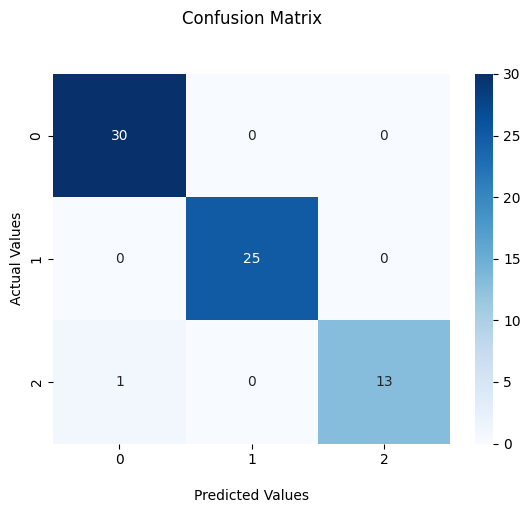

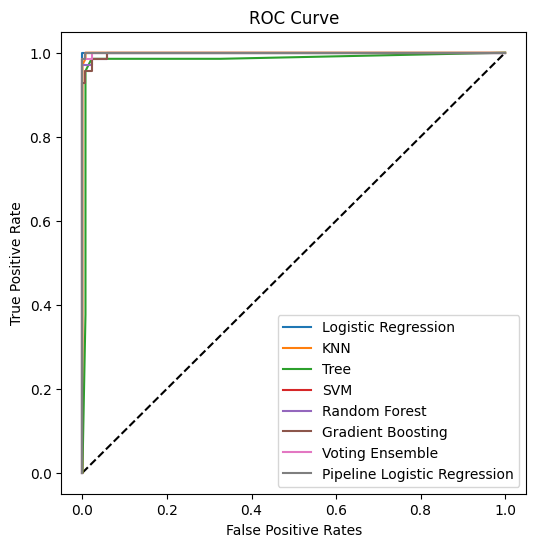

In [18]:
# uzycie pipeline

model_pipeline = make_advanced_lr_pipeline()

model_pipeline.fit(X_train, y_train)

metrics_results, roc_results = calculate_metrics(
    model_pipeline,
    "Pipeline Logistic Regression",
    X_test,
    y_test,
    metrics_results,
    roc_results)

In [19]:
metrics_dataframe = pd.DataFrame(metrics_results)

metrics_dataframe.sort_values(by="F1_score",ascending=False)

,Model,F1_score,AUC
0,Logistic Regression,1.000000,1.000000
6,Voting Ensemble,0.987814,0.999430
7,Pipeline Logistic Regression,0.982190,1.000000
1,KNN,0.982190,0.999858
4,Random Forest,0.970007,0.998712
2,Tree,0.970007,0.988446
3,SVM,0.963606,1.000000
5,Gradient Boosting,0.951430,0.998279
